# EDA General de 'ventas_productos'

In [80]:
##### Importacion de modulos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import os

##### Cambiando directorio
print(os.getcwd())
if os.getcwd().split('\\')[-1] != 'PostSQL':
    os.chdir('./Datos/PostSQL')


c:\Users\JP\Documents\DSProyectos\4_DemandaForecasting\Datos\PostSQL


In [2]:
##### Leyendo y Cargando datos
df = pd.read_csv('ventas_productos.csv')
# df.info()


##### Fechas y Datetime
#### Transformanco fechas a DateTime
df['fecha'] = pd.to_datetime(
    df['fecha'],
    format='%d/%m/%Y',
    dayfirst=True,
    errors='coerce'
)
#### Verificando que todos los datos son del anio 2024
print(df['fecha'].dt.year.unique().tolist())
#### Creando columnas: dia, semana, mes
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.weekday + 1
df['semana'] = df['fecha'].dt.isocalendar().week
df['mes'] = df['fecha'].dt.month
#### Ordenando datos por fecha
df = df.drop(columns='fecha')\
    .sort_values(by=['mes','dia'], ascending=[True, True])\
    .reset_index(drop=True)
#### Rango de fechas: 31/1/24 - 30/12/24
    # 31/1/24 se traslada a la 5ta semana del anio 2024
    # PERO 30/12/25 se traslada a la 1ra semana del anio 2025
        # Ende: Borrar
df = df[~((df['dia']==30) & (df['mes']==12))]


##### Stock
    # El valor de 'stock' es un valor para todo el anio
        # Entonces para diferentes granularidades se tiene
                # que hacer una division igual entre ellas
# len(df['stock'].unique())
# df['stock'] = (df['stock']/52).astype(int)


#### Resumen
df.info()


[2024]
<class 'pandas.DataFrame'>
RangeIndex: 2993 entries, 0 to 2992
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_venta    2993 non-null   int64 
 1   cliente_id  2993 non-null   int64 
 2   cantidad    2993 non-null   int64 
 3   stock       2993 non-null   int64 
 4   nombre      2993 non-null   str   
 5   categoria   2993 non-null   str   
 6   precio      2993 non-null   int64 
 7   dia         2993 non-null   int32 
 8   dia_semana  2993 non-null   int32 
 9   semana      2993 non-null   UInt32
 10  mes         2993 non-null   int32 
dtypes: UInt32(1), int32(3), int64(5), str(2)
memory usage: 213.5 KB


In [3]:
##### Separacion de variables numericas y categoricas
cuant_vars = list(df._get_numeric_data().columns.values)
cual_vars = list(set(df.columns) - set(cuant_vars))
# display(df[cuant_vars].describe())
# display(df[cual_vars].describe())


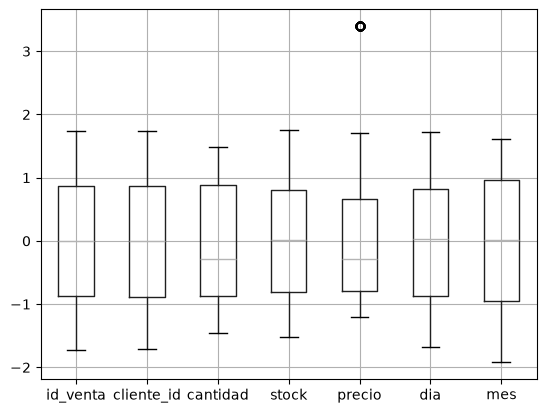

graph for nombre: total = 30


C:\Users\JP\AppData\Local\Temp\ipykernel_5700\512232820.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


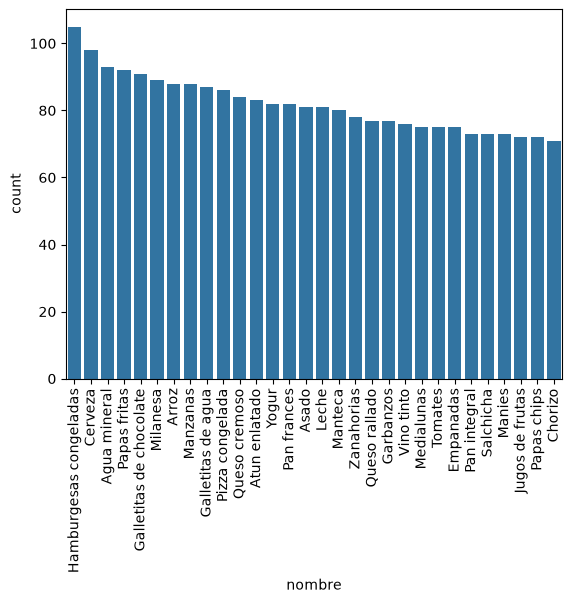

graph for categoria: total = 8


C:\Users\JP\AppData\Local\Temp\ipykernel_5700\512232820.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


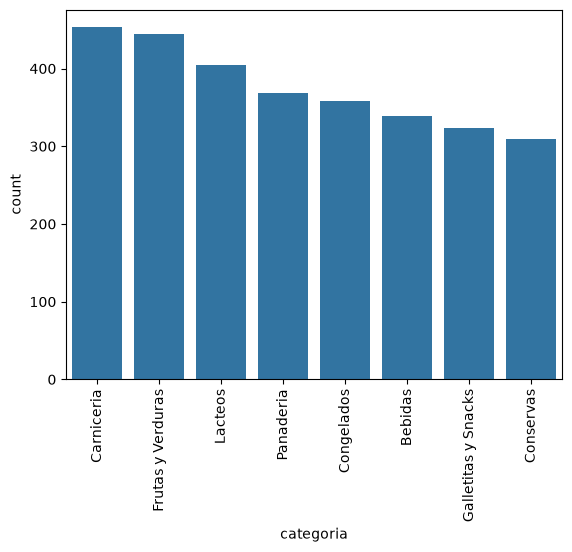

In [59]:
##### Visualizacion
#### Cuant Boxplots
    # Analisis: Solo 'precio' tienen un valor atipico, que es el asado
df_norm = (df[cuant_vars] - df[cuant_vars].mean())/df[cuant_vars].std(ddof=0)
df_norm.boxplot(column=cuant_vars)
plt.show()
del df_norm
#### Cual Histogramas
for col in cual_vars:
    cat_num = df[col].value_counts()[:30]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

,id_venta,cliente_id,cantidad,stock,nombre,categoria,precio,dia,mes
id_venta,1.000,0.015,-0.031,0.025,0.007,0.020,-0.020,-0.001,-0.022
cliente_id,0.015,1.000,-0.021,0.012,0.006,0.013,0.012,0.022,0.004
cantidad,-0.031,-0.021,1.000,0.027,-0.049,-0.036,0.012,-0.001,0.008
stock,0.025,0.012,0.027,1.000,-0.190,0.045,-0.005,0.002,0.016
nombre,0.007,0.006,-0.049,-0.190,1.000,0.305,0.096,-0.018,-0.014
categoria,0.020,0.013,-0.036,0.045,0.305,1.000,-0.225,-0.009,-0.018
precio,-0.020,0.012,0.012,-0.005,0.096,-0.225,1.000,0.014,0.004
dia,-0.001,0.022,-0.001,0.002,-0.018,-0.009,0.014,1.000,-0.013
mes,-0.022,0.004,0.008,0.016,-0.014,-0.018,0.004,-0.013,1.000


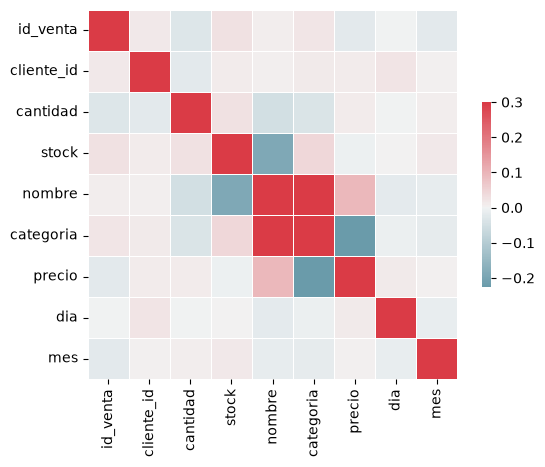

<StringArray>
[            'Bebidas',          'Carniceria',          'Congelados',
           'Conservas',   'Frutas y Verduras', 'Galletitas y Snacks',
             'Lacteos',           'Panaderia']
Length: 8, dtype: str

In [87]:
##### Correlacion
#### Transformando cual varaibles en label encoders
df_corr = df.copy()
le = LabelEncoder()
for col in cual_vars:
    df_corr[col] = le.fit_transform(df[col])
        # El mapping se hace alfabeticamente
        # (Alfabeto -> numero)
#### Visual
display(df_corr.corr().round(3))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df_corr.corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()
##### Analisis
#### Resumen
    # Ninguno de los |valores| < 0.305
    # Ende: no ha correlacon alta entre las variables
#### Neg Corr: Stock y Nombre
display(df['nombre'].sort_values().unique())
    # Parece que los labels numerals, de nombre, con valores
            # altos tienden a ser frutas y verduras, a las
            # cuales generalmente no se hace mucho stock
        # Ende: alto label => bajo stock
#### Neg corr: categoria y precio
display(df['categoria'].sort_values().unique())
    # Cagegoria: Los labels con valores bajos son 'carniceria'
            # y 'bebidas', que generalmente son mas caras
        # Mientras que los valores altos son 'panaderia' y 
                # 'lacteos', que generalmente son mas baratos
        # Ende: alto label de categoria significa mas bajo precios

Tendencias generales del conjunto:
* Columnas:
    - id_venta: cada transaccion es un id diferente
    - cliente_id: cada cliente tiene un diferente is
    - cantidad: la cantidad de un producto (dentro una transaccion) 
            que se vendio
    - stock: cantidad de un producto almacenado
    - nombre: nombre de un producto
    - categoria: categoria de un producto
    - precio: precio de una unidad de un producto
    - fecha: la fecha de una transaccion

Metricas de este proyecto:
* Porcentaje de productos perdidos - Acronimo = PPP
    - ((stock - productos_sold)/stock) * 100
* Popularidad de producto X - Acronimo = PPX
    - (prod_X_sold / total_prod_sold) * 100
* Porcentaje de ingreso X - Acronimo = PIX
* ARPU 
    - total revenue / num_customers
* Transacion value - Acronimo = TV
    - total revenue / num_transactions
    - OJO: la exploracion de abajo demuestra que el conjunto solo tiene 1 transaccion por cliente por semana
        * I.e., considerando un producto en una semana especfica: num transacciones involucrando ese producto = num clientes que compraron ese producto
        * Entonces no hay sentido haciendo esta metrica

Assunciones:
* Se hace el restock 1 vez a la semana
* El stock en el conjunto es la suma de las 52 semanas

In [3]:
##### Funcion que crea DF dependiendo en la granularidad deseada
def df_granularidad(granularidad: str):
    #### Mapa para stock
    stock_gran = {
        'dia': 52,  # No 365, no tiene sentido hacer restock diario
        'dia_semana': 52,   # No 365, no tiene sentido hacer restock diario
        'semana': 52,
        'mes': 12
    }

    #### Creando el df principal
    df_gran = df.groupby(by=[granularidad, 'nombre'], as_index=False)\
        .agg(
            cantidad_comprada = pd.NamedAgg(
                column='cantidad', aggfunc='sum'
            ),
            stock = pd.NamedAgg(
                # column='stock', aggfunc= lambda series: int(series.mean())
                column='stock', aggfunc= lambda series: int(series.mean()/stock_gran[granularidad])
                    # len(df[granularidad].unique()) = dividir el stock equitativamente
            ),
            precio_del_producto = pd.NamedAgg(
                # column='precio', aggfunc = lambda series: series.astype(int)
                column='precio', aggfunc= lambda series: int(series.mean())
            ),
            cantidad_clientes = pd.NamedAgg(
                column='cliente_id', aggfunc=lambda series: series.count()
            ),
            cantidad_trans = pd.NamedAgg(
                column='id_venta', aggfunc= lambda series: series.count()
            )
        )

    df_gran['ingreso'] = df_gran['cantidad_comprada'] * df_gran['precio_del_producto']

    #### Explorando df principal
    df_gran[df_gran['cantidad_clientes'] != df_gran['cantidad_trans']]
        # Esta cantidad es 0 => el conjunto DICE que cada cliente solo hace una 
                # transaccion por la semana, la cual no es realistico
            # Por esta razon: ARPU = TV

    df_gran[df_gran['cantidad_comprada'] > df_gran['stock'] * 0.8]
        # Existen 3 => Hay 3 articulo donde la cantidad vendida es 
                # 0.8*(el stock semanal de ese producto)


    #### Creando metricas
    # display(df_sn.head())
    df_gran['PPP'] = (((df_gran['stock'] - df_gran['cantidad_comprada'])/df_gran['stock']) * 100).round(2)
    df_gran['PPX'] = (
        (
            df_gran['cantidad_comprada'] / \
            df_gran.groupby(by=granularidad)['cantidad_comprada'].transform('sum')
        ) * 100
    ).round(2)
    df_gran['PIX'] = (
        (
            df_gran['ingreso'] / \
            df_gran.groupby(by=granularidad)['ingreso'].transform('sum')
        ) * 100
    ).round(2)
    df_gran['ARPU'] = (
        (
            df_gran.groupby(by=granularidad)['ingreso'].transform('sum') / \
            df_gran.groupby(by=granularidad)['cantidad_clientes'].transform('sum')
        ).round(2)
    )

    # display(df_gran)
    return df_gran


In [4]:
##### Verificando todas las granularidades posibles 
df_dia = df_granularidad('dia')
df_ds = df_granularidad('dia_semana')
df_semana = df_granularidad('semana')
df_mes = df_granularidad('mes')   

#### Dictionario de mapeo
gran_map = {
    'df_dia' : 'dia',
    'df_ds': 'dia_semana',
    'df_semana': 'semana',
    'df_mes': 'mes'
}

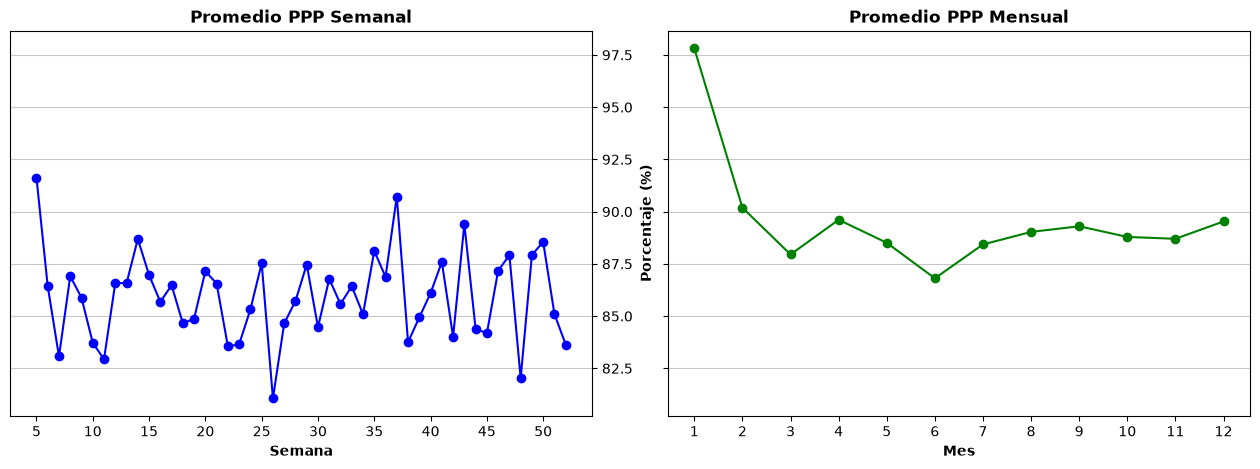

In [ ]:
# ###### Exploracion de PPP
# ##### Viendo como el promedio PPP cambie a traves cada granularidad
# #### Semanas
# df_s_promedi_ppp = df_semana.groupby(by=gran_map['df_semana'], as_index=False)\
#     .agg(
#         promedio_ppp = pd.NamedAgg(
#             column='PPP', aggfunc = lambda series: series.mean().round(2)
#         )
#     ).sort_values(by=gran_map['df_semana'], ascending=True)
#     # .sort_values(by='promedio_ppp', ascending=False)
# #### Meses
# df_m_promedi_ppp = df_mes.groupby(by=gran_map['df_mes'], as_index=False)\
#     .agg(
#         promedio_ppp = pd.NamedAgg(
#             column='PPP', aggfunc = lambda series: series.mean().round(2)
#         )
#     ).sort_values(by=gran_map['df_mes'], ascending=True)
#     # .sort_values(by='promedio_ppp', ascending=False)
# #### Creando figura
# ### Config inicial
# ANCH = 16
# ALT = 5
# fig, axs = plt.subplots(1,2, figsize=(ANCH, ALT), sharey=True)
# ### Plot semanal
# axs[0].plot(
#     np.arange(len(df_semana['semana'].unique())),
#     df_s_promedi_ppp['promedio_ppp'],
#     marker='o',
#     color='blue'
# )
# axs[0].set_title('Promedio PPP Semanal', fontweight='bold')
# axs[0].set_xlabel('Semana', fontweight='bold')
# axs[0].grid(axis='y', alpha=0.7)
# # axs[0].spines['left'].set_position(('axes', 0.5))  # 1.05 = un poco a la derecha del borde derecho del primer subplot
# # axs[0].spines['left'].set_color('none') # Tratar 'red'
# # axs[0].spines['right'].set_color('green')  # Ocultar borde derecho
# axs[0].yaxis.set_ticks_position('right')   # Mantener ticks en el lado izquierdo del eje movido
# axs[0].yaxis.set_label_position('right')
# axs[0].set_ylabel('Porcentaje (%)', fontweight='bold', labelpad=5)
# axs[0].set_xticks(range(len(df_s_promedi_ppp[gran_map['df_semana']])))
# axs[0].set_xticklabels(df_s_promedi_ppp[gran_map['df_semana']])
# axs[0].xaxis.set_major_locator(MultipleLocator(5))
# # axs[0].set_xticks(axs[0].get_xaxis() + 5)
# ### Plot mensual
# axs[1].plot(
#     np.arange(len(df_mes['mes'].unique())),
#     df_m_promedi_ppp['promedio_ppp'],
#     marker='o',
#     color='green'
# )
# axs[1].set_title('Promedio PPP Mensual', fontweight='bold')
# axs[1].set_xlabel('Mes', fontweight='bold')
# axs[1].set_xticks(range(len(df_m_promedi_ppp[gran_map['df_mes']])))
# axs[1].set_xticklabels(df_m_promedi_ppp[gran_map['df_mes']])
# # axs[1].set_ylabel('Porcentaje (%)', fontweight='bold')
# axs[1].grid(axis='y', alpha=0.7)
# axs[1].yaxis.set_visible(True)
# ### Configuraciones finales
# fig.subplots_adjust(wspace=0.13)
# plt.show()





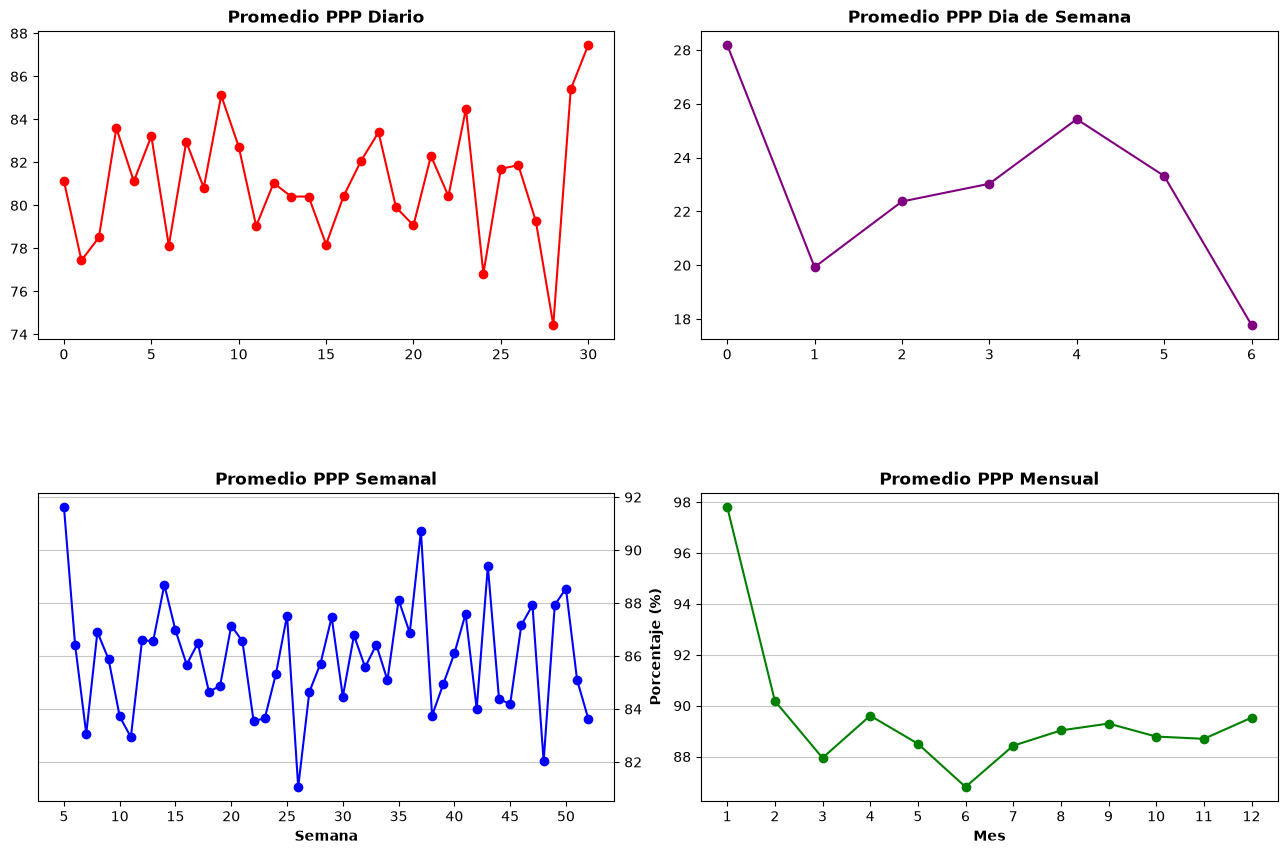

In [115]:
###### Exploracion de PPP
##### Viendo como el promedio PPP cambie a traves cada granularidad
#### Dia
df_d_prom_ppp = df_dia.groupby(by=gran_map['df_dia'], as_index=False)\
    .agg(
        promedio_ppp = pd.NamedAgg(
            column='PPP', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_dia'], ascending=True)
#### Dia Semana
df_ds_prom_ppp = df_ds.groupby(by=gran_map['df_ds'], as_index=False)\
    .agg(
        promedio_ppp = pd.NamedAgg(
            column='PPP', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_ds'], ascending=True)
#### Semanas
df_s_prom_ppp = df_semana.groupby(by=gran_map['df_semana'], as_index=False)\
    .agg(
        promedio_ppp = pd.NamedAgg(
            column='PPP', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_semana'], ascending=True)
    # .sort_values(by='promedio_ppp', ascending=False)
#### Meses
df_m_prom_ppp = df_mes.groupby(by=gran_map['df_mes'], as_index=False)\
    .agg(
        promedio_ppp = pd.NamedAgg(
            column='PPP', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_mes'], ascending=True)
    # .sort_values(by='promedio_ppp', ascending=False)






##### Creando figura
#### Config inicial
ANCH = 16
ALT = 10
fig, axs = plt.subplots(2,2, figsize=(ANCH, ALT))
#### Plots de arriba
### Plot diario
axs[0,0].plot(
    np.arange(len(df_dia['dia'].unique())),
    df_d_prom_ppp['promedio_ppp'],
    marker='o',
    color='red'
)
axs[0,0].set_title('Promedio PPP Diario', fontweight='bold')
### Plot dia semana
axs[0,1].plot(
    np.arange(len(df_ds['dia_semana'].unique())),
    df_ds_prom_ppp['promedio_ppp'],
    marker='o',
    color='purple'
)
axs[0,1].set_title('Promedio PPP Dia de Semana', fontweight='bold')


#### Plots de abajo
### Plot semanal
axs[1,0].plot(
    np.arange(len(df_semana['semana'].unique())),
    df_s_prom_ppp['promedio_ppp'],
    marker='o',
    color='blue'
)
axs[1,0].set_title('Promedio PPP Semanal', fontweight='bold')
axs[1,0].set_xlabel('Semana', fontweight='bold')
axs[1,0].grid(axis='y', alpha=0.7)
# axs[0].spines['left'].set_position(('axes', 0.5))  # 1.05 = un poco a la derecha del borde derecho del primer subplot
# axs[0].spines['left'].set_color('none') # Tratar 'red'
# axs[0].spines['right'].set_color('green')  # Ocultar borde derecho
axs[1,0].yaxis.set_ticks_position('right')   # Mantener ticks en el lado izquierdo del eje movido
axs[1,0].yaxis.set_label_position('right')
axs[1,0].set_ylabel('Porcentaje (%)', fontweight='bold', labelpad=5)
axs[1,0].set_xticks(range(len(df_s_prom_ppp[gran_map['df_semana']])))
axs[1,0].set_xticklabels(df_s_prom_ppp[gran_map['df_semana']])
axs[1,0].xaxis.set_major_locator(MultipleLocator(5))
# axs[0].set_xticks(axs[0].get_xaxis() + 5)
### Plot mensual
axs[1,1].plot(
    np.arange(len(df_mes['mes'].unique())),
    df_m_prom_ppp['promedio_ppp'],
    marker='o',
    color='green'
)
axs[1,1].set_title('Promedio PPP Mensual', fontweight='bold')
axs[1,1].set_xlabel('Mes', fontweight='bold')
axs[1,1].set_xticks(range(len(df_m_prom_ppp[gran_map['df_mes']])))
axs[1,1].set_xticklabels(df_m_prom_ppp[gran_map['df_mes']])
# axs[1].set_ylabel('Porcentaje (%)', fontweight='bold')
axs[1,1].grid(axis='y', alpha=0.7)
axs[1,1].yaxis.set_visible(True)
# ### Configs de plots de abajo
# axs[1,0].sharey(axs[1,1])
# y_bottom = np.concatenate([df_s_promedi_ppp['promedio_ppp'], df_m_promedi_ppp['promedio_ppp']])
# ymin_bottom, ymax_bottom = y_bottom.min(), y_bottom.max()
# axs[1, 0].set_ylim(ymin_bottom - 1, ymax_bottom + 1)

#### Configuraciones finales
fig.subplots_adjust(wspace=0.15, hspace = 0.5)
plt.show()





C:\Users\JP\AppData\Local\Temp\ipykernel_11992\2665480498.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\2665480498.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\2665480498.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\2665480498.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\2665480498.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\


Text(0.5, 1.0, 'Top 5 PPX')

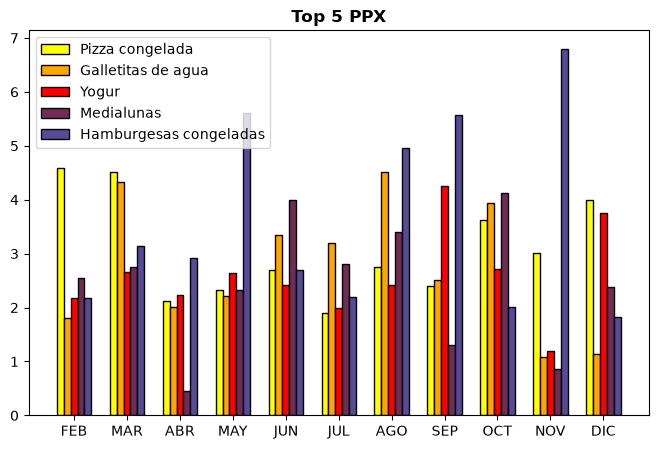

In [154]:
###### Explorando Metrica PPX
    # Viendo los meses cuando un producto es popular
##### Adquiriendo los top X productos
top_X = 5
top_X_prods = df_mes.groupby(by='nombre', as_index=False)\
    .agg(
        ppx_promedio = pd.NamedAgg(
            column='PPX', aggfunc= lambda series: series.mean().round(2)
        )
    ).sort_values(by='ppx_promedio', ascending=False)\
    ['nombre'][:top_X].values.tolist()


##### Visualizacion
#### Configs inicial
colores = ["#ffff00", "#ffa500", "#ff0000", "#702c54", "#584A96",\
        '#D9F0E7', '#A8DED6', '#78C7C9', '#6FA0C8', '#7E77B8',\
        '#24344A', '#445E89', '#6C8AC9', '#8FAAD6', '#B6D1DB',\
        '#14142e', '#74260a', '#be6f37', '#eeb77d', '#f7d8ab',\
        '#ffb74d', '#ff7043', '#8d6e63', '#fbe9e7', '#3e2723',\
        '#d6e6f2', '#4a90e2', '#7daec8', '#b0bec5', '#d8bfe8', \
        "#a3c1da", "#5b9bd5", "#0e4c92", "#f0f4f8", "#1c1c1c"]
ANCH = 8
ALT = 5
WIDTH = 0.13
fig, ax = plt.subplots(figsize=(ANCH, ALT))
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN', 'JUL',\
         'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
#### Creando eje x equilibrado
x = np.arange(len(df_mes['mes'].unique()) - 1)
if top_X % 2 == 0:
    centro = list(range(-1*int(len(top_X_prods)/2),int(len(top_X_prods)/2),1))
else:
    centro = list(range(-1*int(len(top_X_prods)/2),int(len(top_X_prods)/2) + 1,1))

bars = []
#### Visual
for i, prod in enumerate(top_X_prods):
    bars.append(ax.bar(
            x + centro[i]*WIDTH,
            df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
                ['PPX'].values,
            label=prod,
            width=WIDTH,
            color = colores[i],
            edgecolor='black',
            align='center'
        ))
ax.legend()
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses)
ax.set_title(f'Top {top_X} PPX', fontweight = 'bold')
# .sort_values(by=['mes', 'PIX'], ascending=[True, False])\
#     [['mes', 'nombre', 'PIX']]

C:\Users\JP\AppData\Local\Temp\ipykernel_11992\3144301540.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\3144301540.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\3144301540.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\3144301540.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local\Temp\ipykernel_11992\3144301540.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
C:\Users\JP\AppData\Local

Text(0.5, 1.0, 'Top 6 PIX')

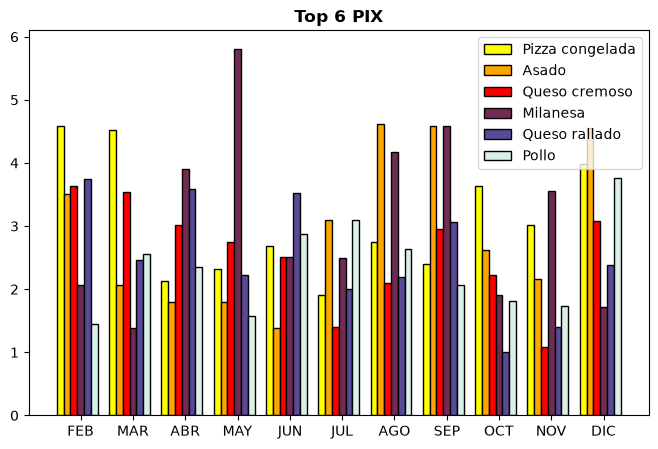

In [153]:
###### Explorando Metrica PIX
    # Viendo los meses cuando un producto es popular
##### Adquiriendo los top X productos
top_X = 6
top_X_prods = df_mes.groupby(by='nombre', as_index=False)\
    .agg(
        pix_promedio = pd.NamedAgg(
            column='PIX', aggfunc= lambda series: series.mean().round(2)
        )
    ).sort_values(by='pix_promedio', ascending=False)\
    ['nombre'][:top_X].values.tolist()


##### Visualizacion
#### Configs inicial
colores = ["#ffff00", "#ffa500", "#ff0000", "#702c54", "#584A96",\
        '#D9F0E7', '#A8DED6', '#78C7C9', '#6FA0C8', '#7E77B8',\
        '#24344A', '#445E89', '#6C8AC9', '#8FAAD6', '#B6D1DB',\
        '#14142e', '#74260a', '#be6f37', '#eeb77d', '#f7d8ab',\
        '#ffb74d', '#ff7043', '#8d6e63', '#fbe9e7', '#3e2723',\
        '#d6e6f2', '#4a90e2', '#7daec8', '#b0bec5', '#d8bfe8', \
        "#a3c1da", "#5b9bd5", "#0e4c92", "#f0f4f8", "#1c1c1c"]
ANCH = 8
ALT = 5
WIDTH = 0.13
fig, ax = plt.subplots(figsize=(ANCH, ALT))
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN', 'JUL',\
         'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
#### Creando eje x equilibrado
x = np.arange(len(df_mes['mes'].unique()) - 1)
if top_X % 2 == 0:
    centro = list(range(-1*int(len(top_X_prods)/2),int(len(top_X_prods)/2),1))
else:
    centro = list(range(-1*int(len(top_X_prods)/2),int(len(top_X_prods)/2) + 1,1))

bars = []
#### Visual
for i, prod in enumerate(top_X_prods):
    bars.append(ax.bar(
            x + centro[i]*WIDTH,
            df_mes[~(df['mes']==1) & (df_mes['nombre']==prod)]\
                ['PPX'].values,
            label=prod,
            width=WIDTH,
            color = colores[i],
            edgecolor='black',
            align='center'
        ))
ax.legend()
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses)
ax.set_title(f'Top {top_X} PIX', fontweight='bold')
# .sort_values(by=['mes', 'PIX'], ascending=[True, False])\
#     [['mes', 'nombre', 'PIX']]

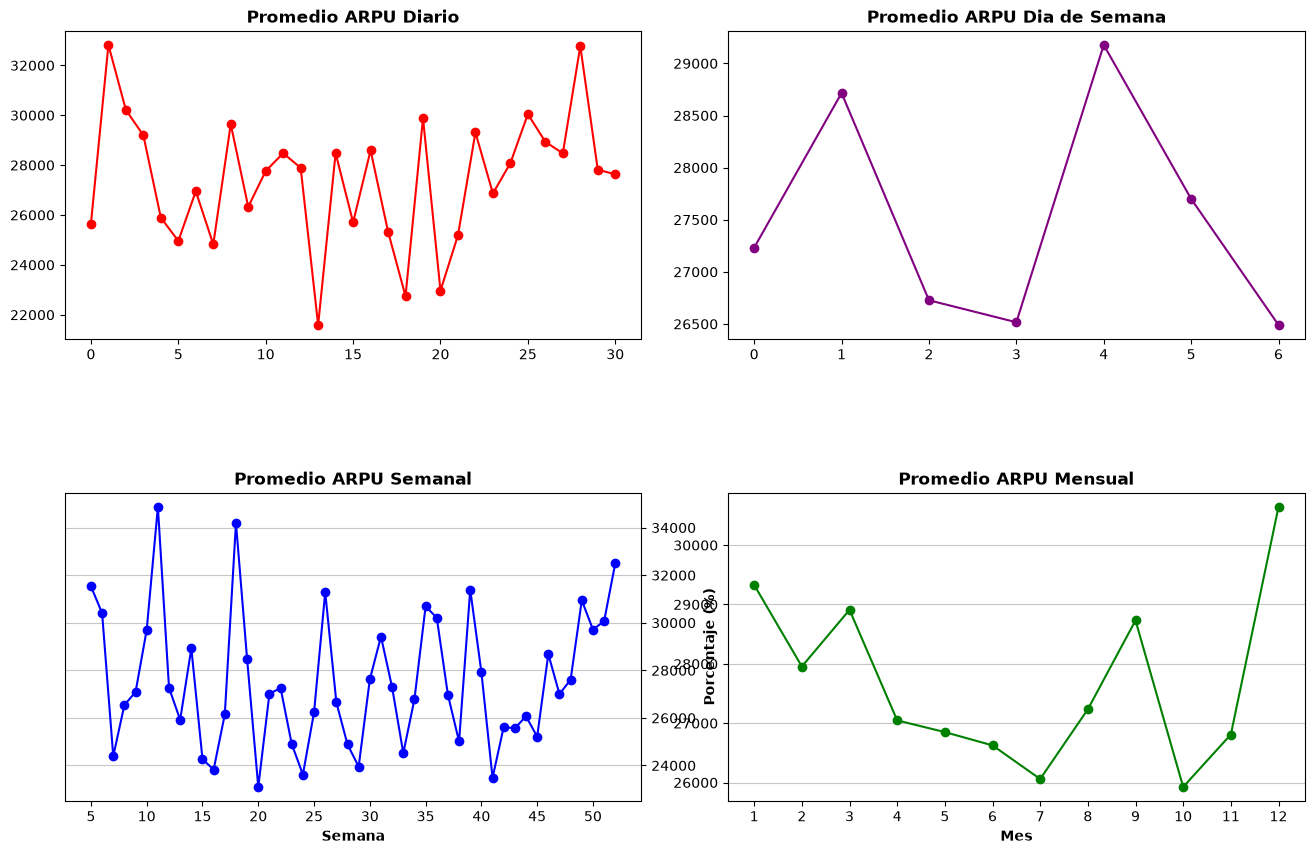

In [ ]:
###### Metrica ARPU
###### Exploracion de ARPU
##### Viendo como el promedio ARPU cambie a traves cada granularidad
#### Dia
df_d_prom_arpu = df_dia.groupby(by=gran_map['df_dia'], as_index=False)\
    .agg(
        promedio_arpu = pd.NamedAgg(
            column='ARPU', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_dia'], ascending=True)
#### Dia Semana
df_ds_prom_arpu = df_ds.groupby(by=gran_map['df_ds'], as_index=False)\
    .agg(
        promedio_arpu = pd.NamedAgg(
            column='ARPU', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_ds'], ascending=True)
#### Semanas
df_s_prom_arpu = df_semana.groupby(by=gran_map['df_semana'], as_index=False)\
    .agg(
        promedio_arpu = pd.NamedAgg(
            column='ARPU', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_semana'], ascending=True)
#### Meses
df_m_prom_arpu = df_mes.groupby(by=gran_map['df_mes'], as_index=False)\
    .agg(
        promedio_arpu = pd.NamedAgg(
            column='ARPU', aggfunc = lambda series: series.mean().round(2)
        )
    ).sort_values(by=gran_map['df_mes'], ascending=True)






##### Creando figura
#### Config inicial
ANCH = 16
ALT = 10
fig, axs = plt.subplots(2,2, figsize=(ANCH, ALT))
#### Plots de arriba
### Plot diario
axs[0,0].plot(
    np.arange(len(df_dia['dia'].unique())),
    df_d_prom_arpu['promedio_arpu'],
    marker='o',
    color='red'
)
axs[0,0].set_title('Promedio ARPU Diario', fontweight='bold')
### Plot dia semana
axs[0,1].plot(
    np.arange(len(df_ds['dia_semana'].unique())),
    df_ds_prom_arpu['promedio_arpu'],
    marker='o',
    color='purple'
)
axs[0,1].set_title('Promedio ARPU Dia de Semana', fontweight='bold')


#### Plots de abajo
### Plot semanal
axs[1,0].plot(
    np.arange(len(df_semana['semana'].unique())),
    df_s_prom_arpu['promedio_arpu'],
    marker='o',
    color='blue'
)
axs[1,0].set_title('Promedio ARPU Semanal', fontweight='bold')
axs[1,0].set_xlabel('Semana', fontweight='bold')
axs[1,0].grid(axis='y', alpha=0.7)
# axs[0].spines['left'].set_position(('axes', 0.5))  # 1.05 = un poco a la derecha del borde derecho del primer subplot
# axs[0].spines['left'].set_color('none') # Tratar 'red'
# axs[0].spines['right'].set_color('green')  # Ocultar borde derecho
axs[1,0].yaxis.set_ticks_position('right')   # Mantener ticks en el lado izquierdo del eje movido
axs[1,0].yaxis.set_label_position('right')
# axs[1,0].set_ylabel('Porcentaje (%)', fontweight='bold', labelpad=5)
axs[1,0].set_xticks(range(len(df_s_prom_ppp[gran_map['df_semana']])))
axs[1,0].set_xticklabels(df_s_prom_ppp[gran_map['df_semana']])
axs[1,0].xaxis.set_major_locator(MultipleLocator(5))
# axs[0].set_xticks(axs[0].get_xaxis() + 5)
### Plot mensual
axs[1,1].plot(
    np.arange(len(df_mes['mes'].unique())),
    df_m_prom_arpu['promedio_arpu'],
    marker='o',
    color='green'
)
axs[1,1].set_title('Promedio ARPU Mensual', fontweight='bold')
axs[1,1].set_xlabel('Mes', fontweight='bold')
axs[1,1].set_xticks(range(len(df_m_prom_ppp[gran_map['df_mes']])))
axs[1,1].set_xticklabels(df_m_prom_ppp[gran_map['df_mes']])
# axs[1].set_ylabel('Porcentaje (%)', fontweight='bold')
axs[1,1].grid(axis='y', alpha=0.7)
axs[1,1].yaxis.set_visible(True)
# ### Configs de plots de abajo
# axs[1,0].sharey(axs[1,1])
# y_bottom = np.concatenate([df_s_promedi_ppp['promedio_ppp'], df_m_promedi_ppp['promedio_ppp']])
# ymin_bottom, ymax_bottom = y_bottom.min(), y_bottom.max()
# axs[1, 0].set_ylim(ymin_bottom - 1, ymax_bottom + 1)

#### Configuraciones finales
fig.subplots_adjust(wspace=0.15, hspace = 0.5)
plt.show()



